# Lab 1 (Week 2) -- worked examples

This notebook walks through the example code in `code/lab1/lab_1.py`, which is
the file the lab sheet points you at when it says *"there is an example in the
repository if you need help"*.

It is **not** the lab solution. It shows you

* Task 1: the pure Python Euclidean distance, and the timing/plotting pattern you
  need for the timing experiment.
* Task 2: how to load the two data files in `data/lab1`.

The tasks themselves -- the Numba version, DTW, the preprocessing pipeline and
the single feature classifier -- are left for you. There are empty cells below to
write them in.

The lab sheet is `Lab Sheet 1.pdf`, and there is a summary in the
repository `README.md`. If you want NumPy practice first, work through
`labW1_Intro_to_Jupyter.ipynb`.

## Setup

`lab_1.py` lives in `code/lab1`, which is not on the import path for this
notebook, so we add it before importing. Everything else is the standard
scientific Python stack.

In [28]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "code" / "lab1"))

import time
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numba import njit

import lab_1

print("repo root:", REPO_ROOT)
print("data dir :", lab_1.DATA_DIR)

repo root: c:\Users\colac\COMP3222-2026
data dir : C:\Users\colac\COMP3222-2026\data\lab1


---

## Task 1: Distance functions and Numba

Measuring distance is fundamental to many ML algorithms. Euclidean distance
between two series of length $m$ is

$$d_e(a, b) = \sqrt{\sum_{i=1}^{m}(a_i - b_i)^2}$$

The lab sheet asks for a single loop, with no input checks -- both series are
assumed to be 1D NumPy arrays of the same length.

In [29]:
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
y = np.array([2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0])

print("ours   :", lab_1.euclidean_distance_python(x, y))
print("numpy  :", np.linalg.norm(x - y))   # sanity check, sqrt(10) = 3.1622...

ours   : 3.1622776601683795
numpy  : 3.1622776601683795


### Task 1.2: the Numba version

Now write the second version yourself. Copy the function above, give it a
different name, and decorate it with `@njit(cache=True)` (see lecture 1.2, slide
40). The body does not change at all -- that is the point.

```python
from numba import njit

@njit(cache=True)
def euclidean_distance_numba(x, y):
    ...
```

`njit` compiles the function to machine code the first time it is called with a
given argument type. `cache=True` writes that compiled code to disk (a
`__pycache__` folder next to the source) so later *runs of the program* do not
pay the compilation cost again.

There is a trap waiting for you in the next section: **the first call is slow**,
because it includes compilation. If you time the first call you will be timing
the compiler, not your code. Call the function once on small inputs before you
start timing, and check for yourself how much difference that makes.

In [30]:
# Your code: the @njit version of euclidean_distance_python.
@njit(cache=True)
def euclidean_distance_better(x: np.ndarray, y: np.ndarray) -> float:
    """Implement a function with a single loop that computes the
       sum of squared differences, then returns the square root."""
    sum_of_squared_differences=0
    for i in range(len(x)):
        sum_of_squared_differences+=(x[i]-y[i])**2
    return math.sqrt(sum_of_squared_differences)

In [31]:
# Your code: time the first call and the second call of your Numba
# function on the same small input. How much of the first call was compilation?
x = np.arange(1.0, 11.0)
y = np.arange(2.0, 12.0)
start = time.time()
print("Numba: ", euclidean_distance_better(x, y))
print(time.time()-start)
start = time.time()
print("Numba: ", euclidean_distance_better(x, y))
print(time.time()-start)

Numba:  3.1622776601683795
0.006542205810546875
Numba:  3.1622776601683795
5.7697296142578125e-05


### Timing experiment

`time_distance` generates two random series of length `n` and times a single
call. The pattern is the one from the lab sheet: read the clock, call the
function, read the clock again.

These functions are fast, so `n` has to be large before the Python version takes
a measurable amount of time. We go up to a million points.

In [32]:
import inspect
print(inspect.getsource(lab_1.time_distance))

def time_distance(distance_function, n: int, random_state: int = 0) -> float:
    """Time a single call of ``distance_function`` on two random series of length n.

    Parameters
    ----------
    distance_function : callable
        Takes two 1D np.ndarray and returns a float.
    n : int
        Length of the random series to generate.
    random_state : int, default=0
        Seed for the random number generator, so runs are repeatable.

    Returns
    -------
    float
        Time taken in seconds.
    """
    rng = np.random.default_rng(random_state)
    x = rng.random(n)
    y = rng.random(n)
    start = time.perf_counter()
    distance_function(x, y)
    return time.perf_counter() - start



In [33]:
sizes, t_py = [], []
for n in range(100_000, 1_000_001, 100_000):
    sizes.append(n)
    t_py.append(lab_1.time_distance(lab_1.euclidean_distance_python, n))
    print(f"n = {n:>9,}  python = {t_py[-1]:.6f}s")

n =   100,000  python = 0.017061s
n =   200,000  python = 0.031298s
n =   300,000  python = 0.046569s
n =   400,000  python = 0.062492s
n =   500,000  python = 0.078747s
n =   600,000  python = 0.094909s
n =   700,000  python = 0.112074s
n =   800,000  python = 0.124751s
n =   900,000  python = 0.140745s
n = 1,000,000  python = 0.157335s


In [34]:
# Your code: time your Numba version over the same sizes into a list t_nb,
# remembering to warm it up first, then estimate the speed-up.
t_nb=[]
for n in range(100_000, 1_000_001, 100_000):
    t_nb.append(lab_1.time_distance(euclidean_distance_better, n))
    print(f"n = {n:>9,}  numba = {t_nb[-1]:.6f}s")

n =   100,000  numba = 0.000046s
n =   200,000  numba = 0.000086s
n =   300,000  numba = 0.000124s
n =   400,000  numba = 0.000162s
n =   500,000  numba = 0.000252s
n =   600,000  numba = 0.000244s
n =   700,000  numba = 0.000287s
n =   800,000  numba = 0.000332s
n =   900,000  numba = 0.000353s
n = 1,000,000  numba = 0.000395s


### Plotting time against n

Both axes are on a log scale. On log--log axes a function whose runtime is
$O(n^k)$ appears as a straight line of gradient $k$, so this should come out
roughly straight with gradient 1 -- it is $O(n)$.

Add your Numba timings as a second line. The two should be parallel, separated
vertically by the speed-up.

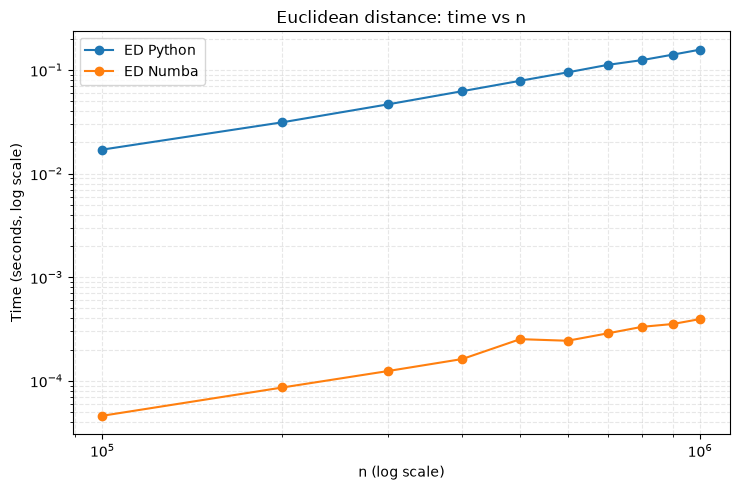

In [35]:
plt.figure(figsize=(7.5, 5.0))
plt.plot(sizes, t_py, marker="o", label="ED Python")
# Your code: plot your Numba timings as a second line.
plt.plot(sizes, t_nb, marker = "o", label="ED Numba")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (log scale)")
plt.ylabel("Time (seconds, log scale)")
plt.title("Euclidean distance: time vs n")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

`lab_1.part1_example()` does all of the above in one call and also saves the
figure to `jit_speed_time_vs_n.png`. Running `python code/lab1/lab_1.py` from a
terminal runs it too.

### Optional extension: Dynamic Time Warping

Do tasks 2 and 3 first, then come back here.

DTW is an $O(n^2)$ time series distance that can compensate for misalignment
between two series. Build an $(m+1) \times (m+1)$ cost matrix `C` filled with
infinity, set `C[0, 0] = 0`, then for each `i, j` in `1...m`

```
C[i, j] = (x[i-1] - y[j-1])**2 + min(C[i-1, j-1], C[i-1, j], C[i, j-1])
```

and return `C[m, m]`. Write a plain Python version and an `@njit` version, then
re-run the timing experiment above with much smaller values of `n` -- it is
quadratic, so a million points is far too many -- and estimate the speed-up for
both Euclidean and DTW.

The hint from the lab sheet:

```python
n = len(x)
C = np.full((n + 1, n + 1), np.inf, dtype=np.float64)
C[0, 0] = 0.0
```

In [36]:
def dtw_distance_python(x: np.ndarray, y: np.ndarray) -> float:
    """Your DTW implementation goes here."""
    ...

---

## Task 2: scikit-learn preprocessing and pipelines

Lecture 2 covered three things that often need doing before a model sees the
data: encoding categorical variables, filling in missing values, and putting
features on a comparable scale. `lab_1.py` shows you how to get the two data
files into memory; the preprocessing is yours to write.

### A. Categorical variables -- `one_hot.csv`

Six columns: three continuous (`x1, x2, x3`), one ordinal (`rank`), one nominal
(`colour`), and the class label `y` last. There is no header row, so we pass
`header=None` and supply the names ourselves.

In [37]:
df = pd.read_csv(lab_1.DATA_DIR / "one_hot.csv", header=None,
                 names=["x1", "x2", "x3", "rank", "colour", "y"])
df.head()

,x1,x2,x3,rank,colour,y
0,-0.637843,-1.099631,0.726880,1,BLUE,0
1,-0.956868,-0.203311,0.713396,2,RED,0
2,0.110266,-3.126333,-1.916515,2,GREEN,0
3,1.000967,1.696530,0.629520,3,BLUE,0
4,-0.948198,0.282593,-0.496696,1,GREEN,0


In [38]:
X_cont, rank, colour, y = lab_1.one_hot_example()

(200, 3) (200,) (200,) (200,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


`rank` is ordinal, so its numeric values are meaningful and it can go straight
into the feature matrix as a float column (`np.column_stack`). `colour` is
nominal -- RED is not "more" than BLUE -- so it needs one-hot encoding with
`sklearn.preprocessing.OneHotEncoder`. Note that the encoder expects 2D input,
so you will have to reshape `colour`.

Then sanity check: can you fit a classifier on the result?

In [39]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
# Your code: column_stack the continuous features with rank,
# one-hot encode colour, and fit any classifier on the result.
colour_2d = colour.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
encoded_colour = encoder.fit_transform(colour_2d)

X_final = np.column_stack((X_cont, rank, encoded_colour))

clf = KNeighborsClassifier()
clf.fit(X_final, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### B. Missing values -- `missing.csv`

Four columns this time: three continuous features and the label. Missing values
appear either as a blank cell or as the text `NaN`; `pd.read_csv` reads both as
`np.nan`.

In [40]:
X_missing, y_missing = lab_1.missing_example()
pd.DataFrame(X_missing, columns=["x1", "x2", "x3"]).head(8)

X shape (200, 3), 8 missing values


,x1,x2,x3
0,-0.637843,-1.099631,0.726880
1,-0.956868,-0.203311,0.713396
2,0.110266,-3.126333,-1.916515
3,NaN,1.696530,0.629520
4,-0.948198,NaN,-0.496696
5,1.163326,0.087972,1.446579
6,0.928831,1.563030,0.242051
7,0.839486,0.300472,NaN


In [41]:
# Missing values per column
pd.DataFrame(X_missing, columns=["x1", "x2", "x3"]).isna().sum()

x1    2
x2    3
x3    3
dtype: int64

Now explore `sklearn.impute` and use one of them -- `SimpleImputer` is the
obvious starting point -- to fill in the gaps.

In [42]:
# Your code: impute the missing values.
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="mean")
X_imputed=imputer.fit_transform(X_missing)
print("Imputed Data (First 8 rows):")
print(pd.DataFrame(X_imputed, columns=["x1", "x2", "x3"]).head(8))

missing_count = np.isnan(X_imputed).sum()
print(f"\nRemaining missing values: {missing_count}")

Imputed Data (First 8 rows):
         x1        x2        x3
0 -0.637843 -1.099631  0.726880
1 -0.956868 -0.203311  0.713396
2  0.110266 -3.126333 -1.916515
3  0.225114  1.696530  0.629520
4 -0.948198  0.236421 -0.496696
5  1.163326  0.087972  1.446579
6  0.928831  1.563030  0.242051
7  0.839486  0.300472  0.298904

Remaining missing values: 0


### C. Scaling / standardisation

`StandardScaler` from `sklearn.preprocessing` centres each feature on zero and
scales it to unit variance. Apply it to the imputed data.

In [43]:
# Your code: standardise the imputed data.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_imputed)

### D. Pipelines

A `Pipeline` chains the preprocessing steps and the model into a single
estimator, so `fit` and `predict` apply the whole sequence. This matters for
correctness as well as tidiness -- the scaler is fitted on the training data
only, which is what you want.

```python
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", KNeighborsClassifier()),
])
```

To go further, look at `ColumnTransformer` for the `one_hot` data, which mixes
categorical and continuous columns and so needs different treatment per
column.

In [44]:
# Your code: build the pipeline.
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

### E. Train/test split

Always evaluate on data the model has not seen.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
```

There is much more on evaluation in Week 5.

In [45]:
# Your code: split, fit and predict.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_missing, y_missing, test_size=0.2, random_state=42, shuffle=True        
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Model's predictions: ", y_pred)
print("Actual true answers: ", y_test)

accuracy = pipe.score(X_test, y_test)
print(f"\nOverall Accuracy: {accuracy * 100}%")

Model's predictions:  [1 0 0 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 0]
Actual true answers:  [0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1
 1 1 0]

Overall Accuracy: 72.5%


---

## Task 3: Implement your own classifier

Write a classifier that follows the scikit-learn conventions, so it works with
`Pipeline`, `train_test_split` and everything else later in the module. It uses
a decision rule on a single feature, and only handles binary problems.

* **Constructor** -- store the index of the feature to use (default 0). By the
  scikit-learn convention the constructor only stores its arguments; it does no
  work and reads no data.
* **`fit`** -- take the chosen column, find its mean for each class, and set the
  threshold to the median of all values in that column. Whichever class has the
  lower mean becomes the "less than" prediction. Attributes learned in `fit` end
  with an underscore, e.g. `self.threshold_`.
* **`predict`** -- apply the rule to the chosen column of each case. If the
  class 0 mean was the smaller one, predict class 0 when `value < threshold`,
  otherwise class 1.

Inheriting from `BaseEstimator` and `ClassifierMixin` gets you `get_params`,
`set_params` and `score` for free.

In [46]:
from sklearn.base import BaseEstimator, ClassifierMixin


class SingleFeatureClassifier(ClassifierMixin, BaseEstimator):
    """Classify on a threshold applied to one feature."""

    def __init__(self, feature_index: int = 0):
        self.feature_index = feature_index

    def fit(self, X, y):
        # Your code: class means for the chosen column, the median threshold,
        # and which side of the threshold is class 0.
        column_data = X[:, self.feature_index]
        self.threshold_ = np.median(column_data)
        class_0_mean = np.mean(column_data[y == 0])
        class_1_mean = np.mean(column_data[y == 1])
        if class_0_mean < class_1_mean:
            self.less_than_class_ = 0
            self.greater_than_class_ = 1
        else:
            self.less_than_class_ = 1
            self.greater_than_class_ = 0
        ...
        return self

    def predict(self, X):
        # Your code: apply the rule.
        column_data = X[:, self.feature_index]
        predictions = np.where(
            column_data < self.threshold_, 
            self.less_than_class_, 
            self.greater_than_class_
        )
        return predictions
        ...

In [47]:
# Your code: test it. Fit on some data and check the accuracy is
# better than guessing.
my_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("clf", SingleFeatureClassifier(feature_index=0))
])

my_pipe.fit(X_train, y_train)

y_pred = my_pipe.predict(X_test)
print("Accuracy:", my_pipe.score(X_test, y_test))

Accuracy: 0.625


If you finish early, explore the range of classifiers in scikit-learn -- we
will be using them next week.